In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Recon Sensor tool

## Cybersecurity Threat Detection Dataset

Labeled network traffic data for intrusion and threat detection research

https://www.kaggle.com/datasets/dhrubangtalukdar/cybersecurity-threat-detection-dataset/data


In [2]:
df5 = pd.read_csv("/content/cybersecurity.csv")

In [3]:
print(df5.shape)
print(df5.dtypes)

(10000, 13)
timestamp              object
src_ip                 object
dst_ip                 object
src_port                int64
dst_port                int64
protocol               object
bytes_sent              int64
bytes_received          int64
user_agent             object
url                    object
is_internal_traffic      bool
label                   int64
attack_type            object
dtype: object


In [4]:
print(df5["label"].value_counts())

label
0    9600
1     400
Name: count, dtype: int64


In [5]:
print(df5.groupby("label")["attack_type"].value_counts(dropna=False))

label  attack_type        
0      benign                 9600
1      brute-force             108
       port-scan                81
       sql-injection            64
       xss                      34
       credential-stuffing      28
       ddos                     27
       command-injection        26
       exploit-attempt          22
       c2                       10
Name: count, dtype: int64


In [6]:
print(df5["src_ip"].nunique(), df5.shape[0])

10000 10000


In [7]:
print(df5["user_agent"].value_counts().head(10))

user_agent
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36                            3458
Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36                      2485
Mozilla/5.0 (iPhone; CPU iPhone OS 16_6 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/16.6 Mobile/15E148 Safari/604.1    1205
curl/8.4.0                                                                                                                                  806
python-requests/2.31.0                                                                                                                      581
Mozilla/5.0 (compatible; Googlebot/2.1; +http://www.google.com/bot.html)                                                                    466
Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:109.0) Gecko/20100101 Firefox/115.0                                             

In [8]:
print(df5["url"].value_counts().head(10))

url
https://api.service.io/config.php?id=923521           1
https://app.company.in/api/v1/users?id=992821         1
https://portal.example.org/test.php?id=968336         1
https://api.service.io/phpmyadmin?id=389892           1
https://portal.example.org/admin?id=271856            1
https://internal.bank.local/login?id=184562           1
https://api.service.io/wp-login.php?id=495927         1
https://api.service.io/config.php?id=223419           1
https://portal.example.org/login?id=889979            1
https://internal.bank.local/api/v1/users?id=466911    1
Name: count, dtype: int64


In [9]:
df5.describe()

,src_port,dst_port,bytes_sent,bytes_received,label
count,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000
mean,27052.223700,2027.280500,1.412572e+05,2.620883e+05,0.040000
std,20978.783832,6769.141395,2.128140e+06,3.767695e+06,0.195969
min,21.000000,5.000000,1.700000e+01,3.000000e+00,0.000000
25%,6092.250000,25.000000,7.148250e+03,1.096075e+04,0.000000
50%,25431.500000,443.000000,2.181550e+04,3.747300e+04,0.000000
75%,45215.750000,1433.000000,6.509525e+04,1.213795e+05,0.000000
max,65524.000000,65491.000000,1.391704e+08,2.914830e+08,1.000000


In [10]:
df5.dtypes

,0
timestamp,object
src_ip,object
dst_ip,object
src_port,int64
dst_port,int64
protocol,object
bytes_sent,int64
bytes_received,int64
user_agent,object
url,object


In [11]:
df5.head()

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,False,0,benign
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign


In [12]:
print(df5.isna().sum())

timestamp                 0
src_ip                    0
dst_ip                    0
src_port                  0
dst_port                  0
protocol                  0
bytes_sent                0
bytes_received            0
user_agent                0
url                    3232
is_internal_traffic       0
label                     0
attack_type               0
dtype: int64


In [13]:
print(df5.duplicated().sum())

0


In [14]:
print(df5["protocol"].value_counts())

protocol
TCP     7765
UDP     1910
ICMP     325
Name: count, dtype: int64


In [15]:
#%%
print(df5.groupby("protocol")["url"].apply(lambda x: x.isna().sum()))

protocol
ICMP     123
TCP     2463
UDP      646
Name: url, dtype: int64


In [16]:
df5["url"] = df5["url"].fillna("")

In [ ]:
## Feature Engineering

In [17]:
suspicious_ua_keywords = ["curl", "python-requests", "python-urllib", "sqlmap", "zgrab", "nmap", "nikto", "masscan"]


In [18]:
df5["ua_is_suspicious_tool"] = df5["user_agent"].str.lower().apply(
    lambda ua: any(kw in ua for kw in suspicious_ua_keywords)
).astype(int)


In [19]:
df5["ua_length"] = df5["user_agent"].str.len()

In [20]:
print(df5.groupby("label")["ua_is_suspicious_tool"].mean())

label
0    0.189271
1    0.442500
Name: ua_is_suspicious_tool, dtype: float64


In [21]:
suspicious_url_keywords = ["admin", "login", "wp-login", "phpmyadmin", "config", ".php", "select", "union", "--", "<script", "../"]


In [22]:
df5["url_length"] = df5["url"].str.len()
df5["url_num_params"] = df5["url"].str.count(r"[?&]\w+=")

In [23]:
df5["url_has_suspicious_keyword"] = df5["url"].str.lower().apply(
    lambda u: any(kw in u for kw in suspicious_url_keywords)
).astype(int)

In [24]:
print(df5.groupby("label")["url_has_suspicious_keyword"].mean())

label
0    0.29125
1    0.28000
Name: url_has_suspicious_keyword, dtype: float64


In [25]:
print(df5.groupby("label")[["url_length", "url_num_params"]].mean())

       url_length  url_num_params
label                            
0          29.055        0.676979
1          29.095        0.672500


In [27]:
#%%
tmp = df5.groupby("label")[["bytes_sent", "bytes_received", "src_port", "dst_port"]].describe()

In [28]:
print(tmp)

      bytes_sent                                                               \
           count          mean           std   min      25%      50%      75%   
label                                                                           
0         9600.0  7.917183e+04  2.497565e+05  17.0  7239.25  22089.5  65304.5   
1          400.0  1.631307e+06  1.047271e+07  43.0  4540.25  16965.0  59340.5   

                   bytes_received                ... src_port           \
               max          count          mean  ...      75%      max   
label                                            ...                     
0        8576473.0         9600.0  1.677655e+05  ...  45491.5  65524.0   
1      139170405.0          400.0  2.525835e+06  ...  35458.5  65310.0   

      dst_port                                                                 
         count         mean          std   min   25%    50%      75%      max  
label                                                          

In [29]:
# Apply Log-Transform
df5["log_bytes_sent"] = np.log1p(df5["bytes_sent"])
df5["log_bytes_received"] = np.log1p(df5["bytes_received"])

In [30]:
protocol_dummies = pd.get_dummies(df5["protocol"], prefix="proto")

In [31]:
features = pd.concat([
    df5[["src_port", "dst_port", "log_bytes_sent", "log_bytes_received",
         "is_internal_traffic", "ua_is_suspicious_tool", "ua_length"]],
    protocol_dummies
], axis=1)

In [32]:
features["is_internal_traffic"] = features["is_internal_traffic"].astype(int)

In [33]:
print(features.shape)
print(features.dtypes)

(10000, 10)
src_port                   int64
dst_port                   int64
log_bytes_sent           float64
log_bytes_received       float64
is_internal_traffic        int64
ua_is_suspicious_tool      int64
ua_length                  int64
proto_ICMP                  bool
proto_TCP                   bool
proto_UDP                   bool
dtype: object


In [35]:
print(df5.head())
print(df5.info())

             timestamp           src_ip           dst_ip  src_port  dst_port  \
0  2025-10-01 00:12:54   188.176.27.165  253.240.113.218     56377       445   
1  2025-10-01 00:23:43      68.59.26.43    212.75.38.111     51165      1433   
2  2025-10-01 00:25:46   119.204.243.78     90.28.90.234     14948      1433   
3  2025-10-01 00:27:21  122.119.194.175   175.140.78.230     36097       443   
4  2025-10-01 00:40:09   181.199.242.68     55.99.177.69       445     21255   

  protocol  bytes_sent  bytes_received  \
0      TCP        8029           17204   
1      TCP      676368         2643374   
2      TCP      316502           38571   
3      TCP       70933           21935   
4      TCP       12721            9939   

                                          user_agent  \
0  Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
1  Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
2  Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...   
3  Mozilla/5.0 (Windows NT 10.0; Win64; x6

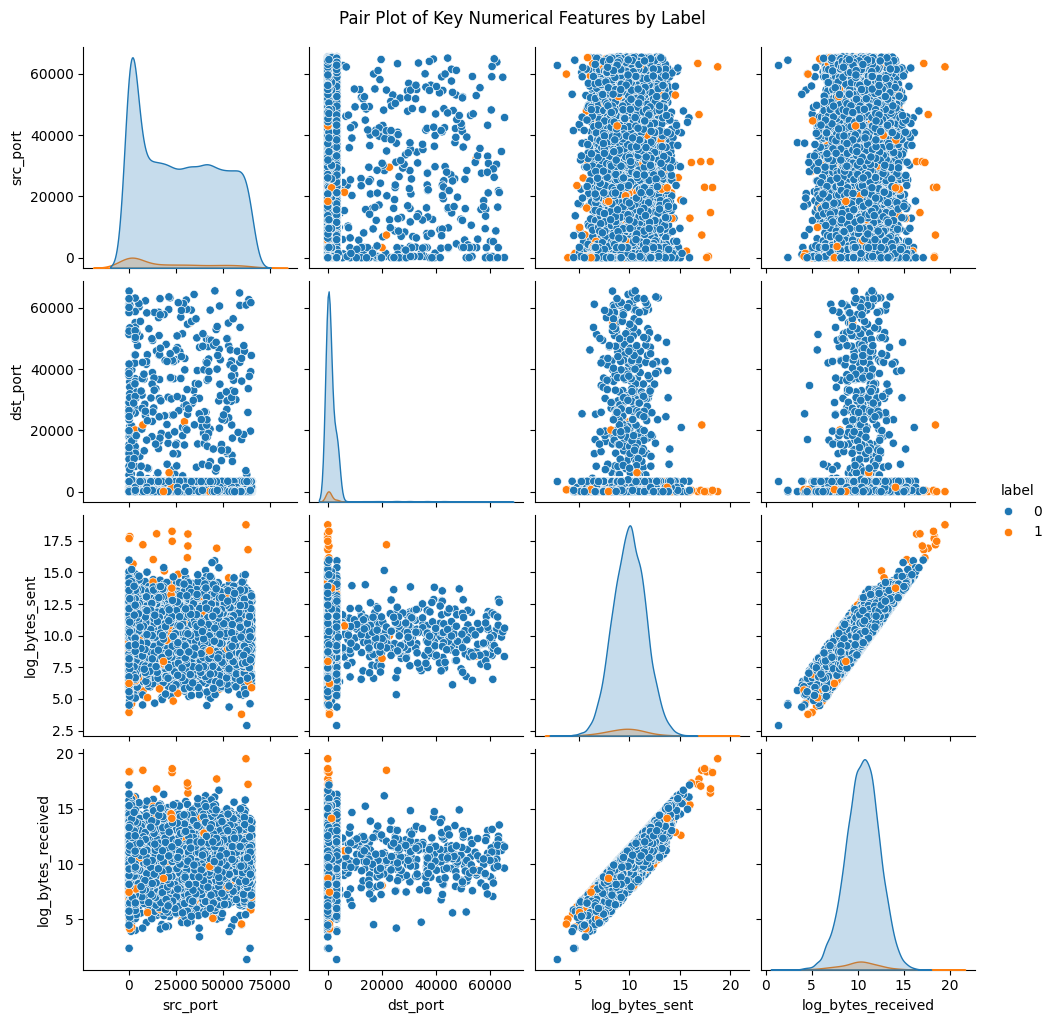

In [37]:
# Pair-Plots
sns.pairplot(df5[[ "src_port", "dst_port", "log_bytes_sent", "log_bytes_received", "label"]], hue="label")
plt.suptitle("Pair Plot of Key Numerical Features by Label", y=1.02)
plt.show()

From the pair plot, we can observe:

log_bytes_sent and log_bytes_received appear to be highly correlated, as expected, with a cluster of attack samples exhibiting higher values.
The distributions of src_port and dst_port are wide, with some distinctions between benign and attack traffic.
Attack samples (orange) are interspersed among benign samples (blue) across most plots, indicating that a simple linear separation might be challenging.

In [38]:
numerical_features = df5.select_dtypes(include=[np.number, 'bool']).columns
correlation_matrix = df5[numerical_features].corr()
display(correlation_matrix)

,src_port,dst_port,bytes_sent,bytes_received,is_internal_traffic,label,ua_is_suspicious_tool,ua_length,url_length,url_num_params,url_has_suspicious_keyword,log_bytes_sent,log_bytes_received
src_port,1.000000,-0.012776,0.002716,0.003754,-0.001771,-0.076940,-0.021734,0.018874,-0.003241,-0.006066,0.001258,0.000455,0.005309
dst_port,-0.012776,1.000000,-0.004669,0.000800,-0.008328,-0.030122,0.003104,0.002957,0.010583,0.014571,-0.000700,-0.008425,-0.004340
bytes_sent,0.002716,-0.004669,1.000000,0.876734,-0.004571,0.142928,0.013105,-0.014135,-0.008020,-0.006382,-0.009516,0.199319,0.170952
bytes_received,0.003754,0.000800,0.876734,1.000000,0.000724,0.122650,0.020990,-0.022917,-0.003920,-0.003720,-0.006339,0.190653,0.182138
is_internal_traffic,-0.001771,-0.008328,-0.004571,0.000724,1.000000,-0.001926,-0.022141,0.018181,-0.018188,-0.019705,-0.023273,0.006241,0.004134
label,-0.076940,-0.030122,0.142928,0.122650,-0.001926,1.000000,0.124196,-0.118982,0.000381,-0.001877,-0.004854,-0.016563,-0.016150
ua_is_suspicious_tool,-0.021734,0.003104,0.013105,0.020990,-0.022141,0.124196,1.000000,-0.942503,0.009514,0.008274,0.011653,0.024740,0.023061
ua_length,0.018874,0.002957,-0.014135,-0.022917,0.018181,-0.118982,-0.942503,1.000000,-0.013549,-0.012667,-0.016757,-0.021421,-0.023597
url_length,-0.003241,0.010583,-0.008020,-0.003920,-0.018188,0.000381,0.009514,-0.013549,1.000000,0.977160,0.422227,0.007014,0.002202
url_num_params,-0.006066,0.014571,-0.006382,-0.003720,-0.019705,-0.001877,0.008274,-0.012667,0.977160,1.000000,0.442505,0.010677,0.004802


### Key observations from the correlation matrix:

bytes_sent and bytes_received: There is a strong positive correlation between bytes_sent and bytes_received (0.876734), which is expected as network communication often involves bidirectional data transfer. The log-transformed versions, log_bytes_sent and log_bytes_received, also show a strong positive correlation (0.888837).

In [39]:
print(df5.groupby('ua_is_suspicious_tool')['ua_length'].mean())

ua_is_suspicious_tool
0    112.686735
1     14.984453
Name: ua_length, dtype: float64


When ua_is_suspicious_tool is 0 (meaning the user agent is not identified as a suspicious tool), the average ua_length is approximately 112.69 characters.
When ua_is_suspicious_tool is 1 (meaning the user agent is identified as a suspicious tool), the average ua_length is approximately 14.98 characters.

In [41]:
## Features Selections

In [40]:
features["proto_ICMP"] = features["proto_ICMP"].astype(int)
features["proto_TCP"] = features["proto_TCP"].astype(int)
features["proto_UDP"] = features["proto_UDP"].astype(int)

In [42]:
X5 = features
y5 = df5["label"]

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5, y5, test_size=0.2, stratify=y5, random_state=42
)


In [45]:
print(y5_train.value_counts())

label
0    7680
1     320
Name: count, dtype: int64


In [46]:
from xgboost import XGBClassifier

In [47]:
scale_pos_weight = (y5_train == 0).sum() / (y5_train == 1).sum()

In [48]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

In [49]:
xgb_model.fit(X5_train, y5_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [53]:
from sklearn.metrics import classification_report, roc_curve, roc_auc_score

In [54]:
y5_pred = xgb_model.predict(X5_test)
y5_proba = xgb_model.predict_proba(X5_test)[:, 1]

In [55]:
print(classification_report(y5_test, y5_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9839    0.9854    0.9846      1920
           1     0.6364    0.6125    0.6242        80

    accuracy                         0.9705      2000
   macro avg     0.8101    0.7990    0.8044      2000
weighted avg     0.9700    0.9705    0.9702      2000



In [56]:
print("ROC AUC:", roc_auc_score(y5_test, y5_proba))

ROC AUC: 0.8622591145833333


## Features Importance

In [57]:
importances = pd.Series(xgb_model.feature_importances_, index=X5.columns).sort_values(ascending=False)


In [58]:
print(importances)

ua_is_suspicious_tool    0.386149
dst_port                 0.153254
ua_length                0.108312
src_port                 0.087264
log_bytes_sent           0.074150
proto_UDP                0.064191
log_bytes_received       0.040954
is_internal_traffic      0.036210
proto_ICMP               0.034778
proto_TCP                0.014737
dtype: float32


In [59]:
import joblib

In [60]:
joblib.dump(xgb_model, "recon_sensor_xgb_model.joblib")

['recon_sensor_xgb_model.joblib']

In [63]:
import json

In [64]:
# Save Model metadata for backend
metadata5 = {
    "model": "recon_sensor_xgb",
    "classes": {"0": "BENIGN", "1": "Attack"},
    "source": "Kaggle - Cybersecurity Threat Detection Dataset (synthetic, unverified provenance)",
    "features": list(X5.columns),
    "metrics": {
        "accuracy": 0.9705,
        "precision_class1": 0.6364,
        "recall_class1": 0.6125,
        "f1_class1": 0.6242,
        "roc_auc": 0.8622591145833333
    },
    "reliability_note": "Trained on synthetic data (all src_ip/url unique, no realistic repetition). Treat as a weak/secondary signal in the correlator, not standalone ground truth. URL-based features were tested and discarded (no discriminative power in this dataset)."
}

In [65]:
with open("recon_sensor_xgb_metadata.json", "w") as f:
    json.dump(metadata5, f, indent=2)